# Visualize Upwelling System! Add Wind and Isotherm Depth to Transect plot

In [1]:
library(tidyverse)
library("MBA")
library("colorRamps")
library(reshape2)
library(cowplot)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attache Paket: ‘reshape2’


Das folgende Objekt ist maskiert ‘package:tidyr’:

    smiths



Attache Paket: ‘cowplot’


Das folgende Objekt ist maskiert ‘package:lubridate’:

    stamp




In [2]:
niskin_raw_int <- readRDS("../processed/Niskin_interpolated_raw.RDS")
#niskin_raw_int$time_month = format(niskin_raw_int$date, format="%m-%Y")
#niskin_ds <- niskin_ds %>% select(-date)
unique(niskin_raw_int$variable)

[1] "O2_umol_kg"          "O2_ml_L"             "NO3_UDO"            
 [4] "PO4_UDO"             "SiO4_UDO"            "NH4_USF"            
 [7] "NO2_USF"             "NO3_NO2_USF"         "NO3_USF"            
[10] "PO4_USF"             "SiO4_USF"            "NO3_merged"         
[13] "PO4_merged"          "SiO4_merged"         "pH_corrected"       
[16] "Salinity_bottles"    "Temperature"         "Sigma_t"            
[19] "PrimaryProductivity" "Chlorophyll"         "Phaeopigments"

In [3]:
niskin_raw <- readRDS("../processed/Niskin_RAW.RDS")
#str(niskin_raw)

In [4]:
CARIACO <- readRDS("../processed/CARIACO_EnvData_combined.rds")

In [5]:
CARIACO$Date <- as.Date(paste("15-",CARIACO$time_month, sep=""), "%d-%m-%Y")
CARIACO$decimaldate <- decimal_date(CARIACO$Date)

In [18]:
extract_data <- function(vartopick){
    # subset
    subset_niskin_raw_int <- niskin_raw_int %>% filter(variable==vartopick) %>%
            filter(depth<=200 & depth>=0) %>% na.omit()
    
    subset_niskin_raw_int$dec_date <- decimal_date(subset_niskin_raw_int$date)
    
    subset_niskin_raw <- niskin_raw %>% select(all_of(vartopick), "date", "depth") %>%
            filter(depth<=200 & depth>=0) %>% na.omit() %>% mutate("variable"=vartopick) %>% rename("var"=vartopick)

    return(list(subset_niskin_raw_int, subset_niskin_raw))
}


create_transectplot <- function(vartopick, scalelabel){

    data_list<- extract_data(vartopick)
    subset_niskin_raw_int = data_list[[1]]
    subset_niskin_raw = data_list[[2]]
    
    #interpolate    
    mba <- mba.surf(subset_niskin_raw_int[,c('dec_date', 'depth', 'value_int')], no.X = 1000, no.Y = 1000, extend = TRUE, m = 3, h = 5)   
    dimnames(mba$xyz.est$z) <- list(mba$xyz.est$x, mba$xyz.est$y)
    df3 <- mba$xyz.est$z %>% melt(mba$xyz.est$z, varnames = c('dec_date', 'depth'), value.name = 'var')
    subset_niskin_raw$dec_date <- decimal_date(subset_niskin_raw$date)

    # plot
    transect_plot <- ggplot(data=df3, aes(dec_date, depth)) +
        
        geom_raster(aes(fill = var), interpolate = T, hjust = 0.5, vjust = 0.5) +
        #geom_contour(aes(z = var)) + 
        
        geom_point(data = subset_niskin_raw, aes(dec_date, depth), colour = 'white', alpha = 0.5, shape=20) +
    
        geom_point(data = CARIACO, aes(decimaldate, Isotherm_21), colour = 'white', alpha = 1) +
    
        geom_line(data = CARIACO, aes(decimaldate, Isotherm_21), colour = 'white', alpha = 1, size=1.3) +
    
        scale_x_continuous(expand=c(0,0)) +
        scale_y_reverse(expand=c(0,0)) +
        scale_fill_gradientn(colours = matlab.like2(7))+ 
    
        xlab('Date [years]') + ylab('Depth [m]') + labs(fill=scalelabel) +
        theme_cowplot()

    return(transect_plot)
}

In [19]:
options(repr.plot.width=10, repr.plot.height=4)

no3plot <- create_transectplot("NO3_merged",expression("NO"["3"]~"[µM]"))
#ggsave("transectplot_NO3.pdf",no3plot, width=10, height=5)

po4plot <- create_transectplot("PO4_merged",expression("PO"["4"]~"[µM]"))
#ggsave("transectplot_PO4.pdf",po4plot, width=10, height=5)

sio4plot <- create_transectplot("SiO4_merged",expression("SiO"["4"]~"[µM]"))
#ggsave("transectplot_SiO4.pdf",SiO4plot, width=10, height=5)

Warning message:
“Removed 27 rows containing missing values or values outside the scale range (`geom_point()`).”


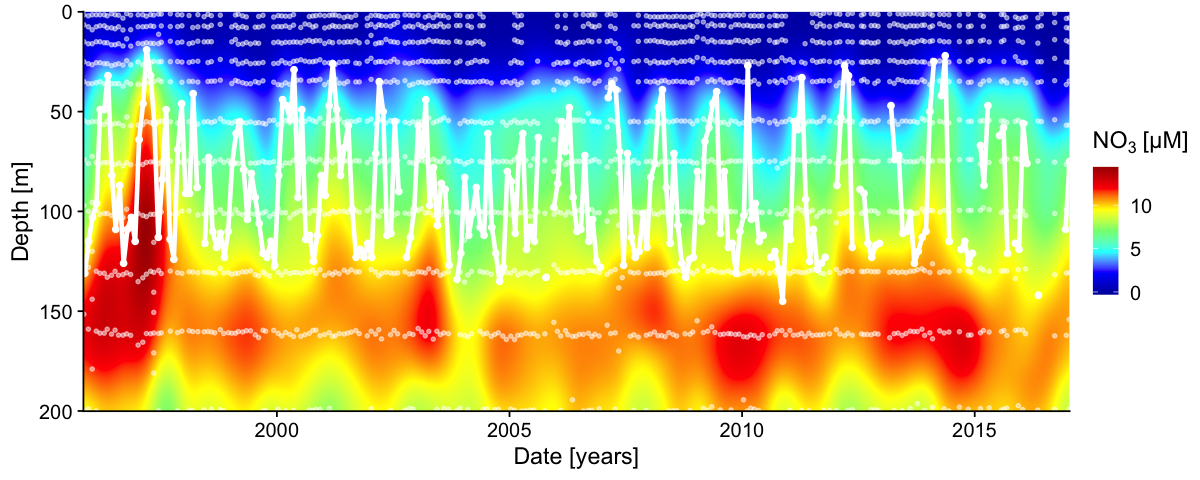

In [20]:
no3plot

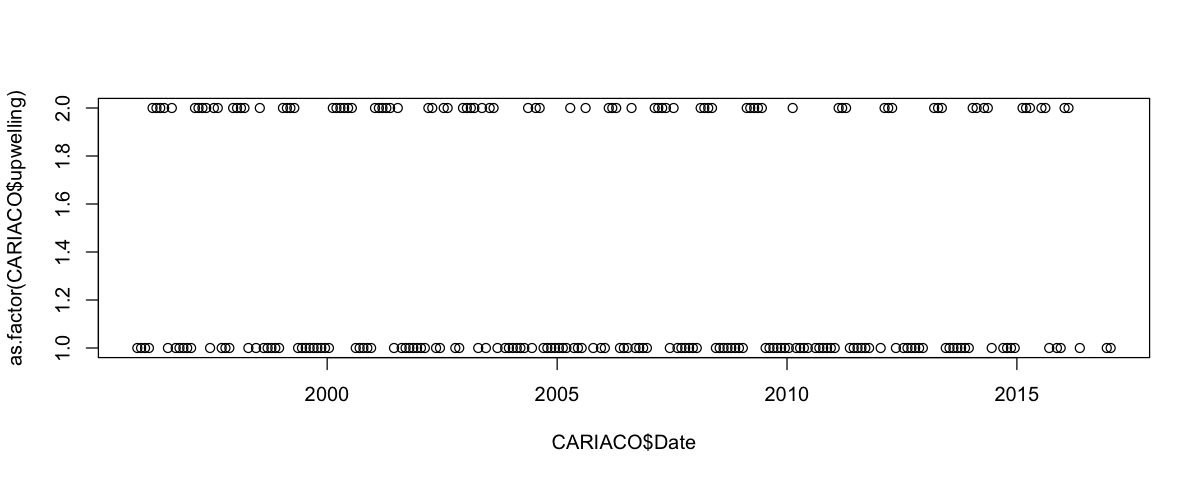

In [25]:
plot(CARIACO$Date, as.factor(CARIACO$upwelling))

Warning message:
“Removed 27 rows containing missing values or values outside the scale range (`geom_point()`).”


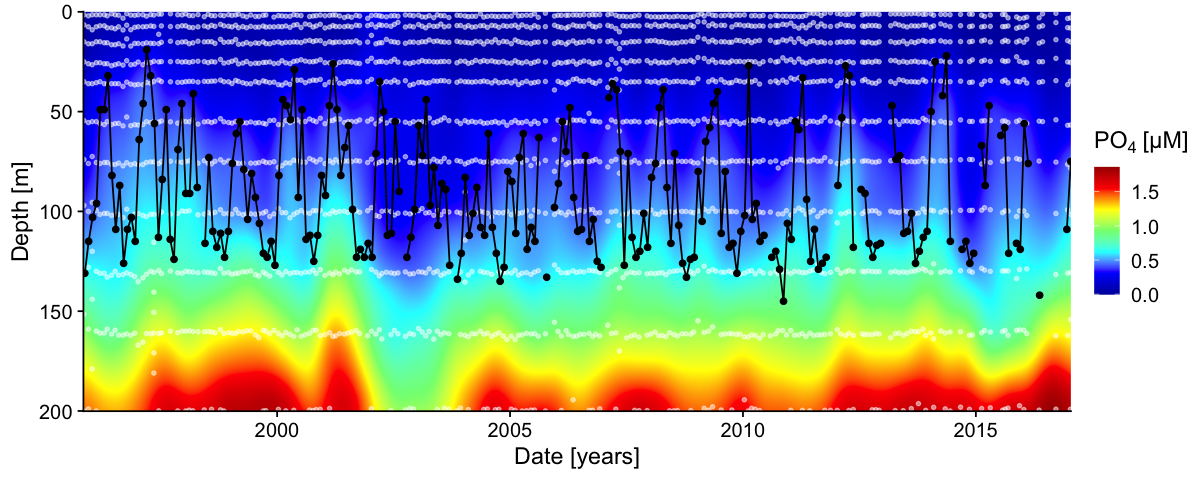

In [49]:
po4plot

Warning message:
“Removed 27 rows containing missing values or values outside the scale range (`geom_point()`).”


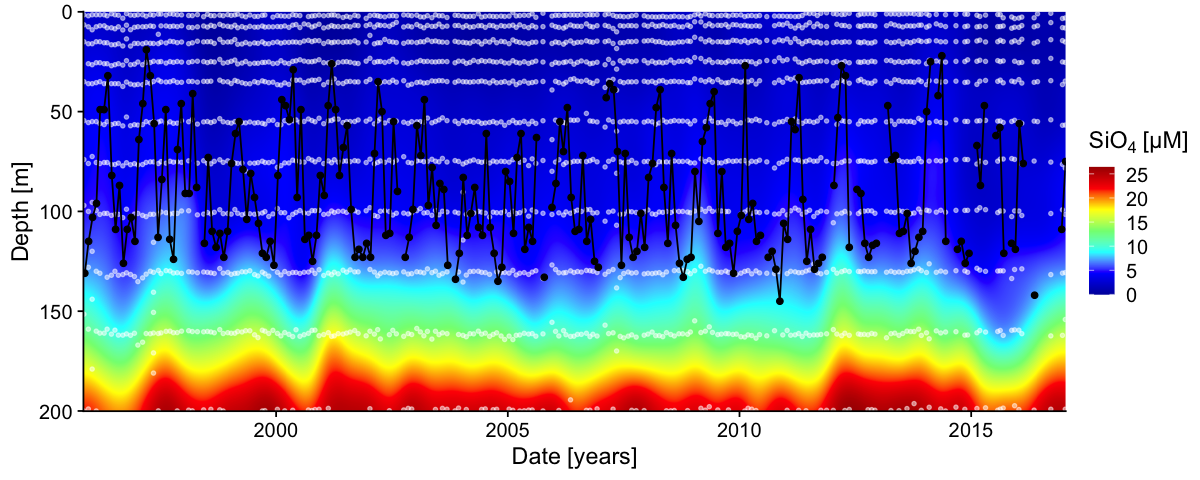

In [50]:
sio4plot

# Alright
now i added the isotherm to the transect plots.. 
shows how messy the data is..

Anyways, now I can proceed to get my years of high and low upwelling, to extract forcing and verification.

I want to base this on Brinque et al. 2018's index of which isotherm reaches 50m.

    Conditions of “weak”, “moderate”, and “strong” upwelling correspond to intervals when the 22, 21, and 20 ◦C isotherms reached 50 m depth, respectively. All other intervals (when SSTs at 50 m are > 22 ◦C) are considered to represent “relaxed” upwelling conditions.

In [55]:
# read MLD and euphotic depth file
MLD2EuZ <- read.csv("../processed/MLD2EuZ_2.csv")

# read Date column
MLD2EuZ$Date <- as.Date(MLD2EuZ$Date, format="%Y-%m-%d")

In [61]:
min(MLD2EuZ$x1, na.rm=T)

max(MLD2EuZ$x1, na.rm=T)

[1] 12.4

[1] 69.09

In [66]:
min(CARIACO$PrimaryProductivity, na.rm=T)*100
mean(CARIACO$PrimaryProductivity, na.rm=T)*100

[1] 24.23011

[1] 110.8846

In [68]:

mean(CARIACO$Temperature, na.rm=T)

[1] 23.14068

In [69]:
# f ratio:

T = 23.14
tp = 111

0.04756 * (0.78 - (0.43*T)/30)*tp**0.307

[1] 0.09052126

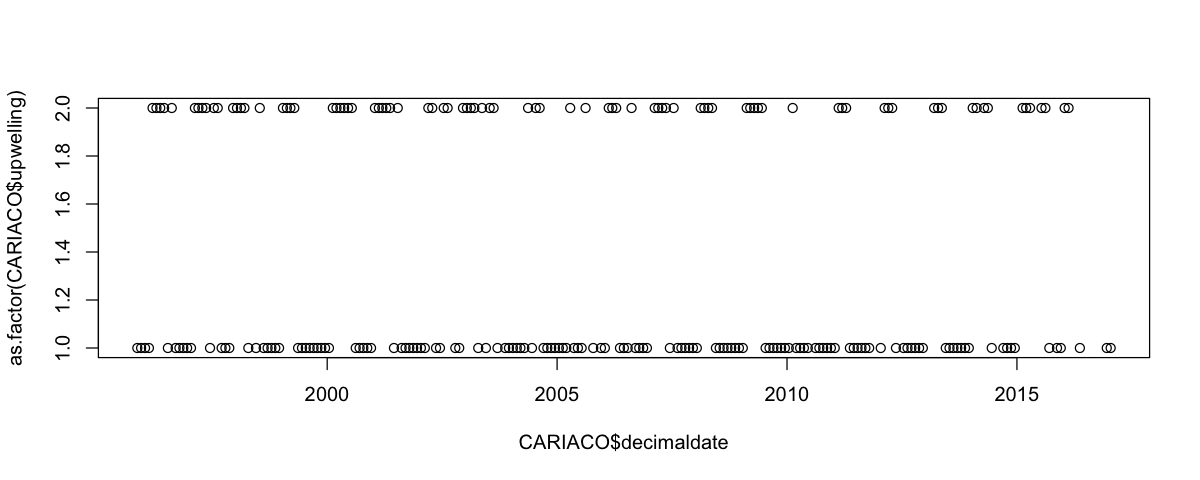

In [38]:
plot(CARIACO$decimaldate, as.factor(CARIACO$upwelling))

In [30]:
inds <- diff(c(0, as.factor(CARIACO$upwelling)))
inds

start <- CARIACO$decimaldate[inds == 1]
end <- CARIACO$decimaldate[inds == -1]
if (length(start) > length(end)) end <- c(end, tail(CARIACO$decimaldate, 1))

[1]  1  0  0  0  1  0  0  0 -1  1 -1  0  0  0  0  1  0  0  0 -1  1  0 -1  0  0
 [26]  1  0  0  0 -1 NA NA  1 -1  0  0  0  0  1  0  0  0 -1  0  0  0  0  0  0  0
 [51]  0  1  0  0  0  0  0 -1  0  0  0  0  1  0  0  0  0 -1  1 -1  0  0  0  0  0
 [76]  0  1  0 -1  0  1  0 NA NA  0  1  0  0  0 -1  1 -1  1  0 -1 NA NA  0  0  0
[101]  0  0  1 -1  1  0 -1  0  0  0  0  0  0  1 -1  0  0  1 NA NA NA NA  0  1  0
[126]  0 -1  0  0  1 -1  0  0  0 NA NA  0  0  0 -1  1 -1  0  0  0  0  0  1  0  0
[151]  0 -1  0  0  0  0  0  0  0  1  0  0  0  0 -1  0  0  0  0  0  0  1 -1  0  0
[176]  0 NA NA  0  0  0  0  0  1  0  0 -1  0  0  0  0  0 NA NA NA  1  0  0 -1 NA
[201] NA  0  0  0  0  0 NA NA NA  0  0 -1  0  0  0  0  0  0  1  0 NA NA  0 -1 NA
[226] NA NA  0  0  0 NA NA  0  0 NA NA NA  0 -1 NA NA  0  1  0 NA NA NA NA NA NA
[251] NA NA NA NA  0

In [35]:
## highlight region data
rects <- data.frame(start=start, end=end, group=seq_along(start))
rects

start,end,group
<dbl>,<dbl>,<int>
1995.871,1996.536,1
1996.202,1996.705,2
1996.620,1997.452,3
1997.123,1997.704,4
1997.534,1998.285,5
1997.953,NA,6
NA,NA,7
NA,1998.619,8
1998.534,1999.367,9


Warning message:
“Removed 27 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range (`geom_rect()`).”


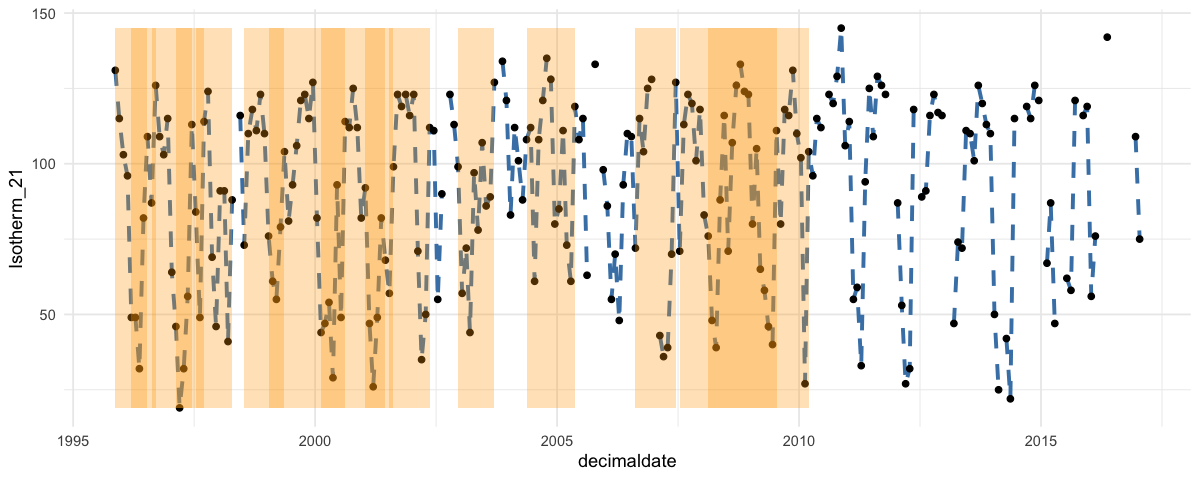

In [37]:

ggplot(data=CARIACO, aes(decimaldate, Isotherm_21)) +
  theme_minimal() +
  geom_line(lty=2, color="steelblue", lwd=1.1) +
  geom_point() +
  geom_rect(data=rects, inherit.aes=FALSE, aes(xmin=start, xmax=end, ymin=min(CARIACO$Isotherm_21, na.rm=T),
                ymax=max(CARIACO$Isotherm_21, na.rm=T), group=group), color="transparent", fill="orange", alpha=0.3)